# Aridity Index (AI)
Extract mean aridity index within a 10 km bounding box for each site.

Source: Zomer et al. (2022) Global Aridity Index v3.1
        https://doi.org/10.6084/m9.figshare.7504448

- Using Annual ETO version (ai_v31_yr.tif) which represents the mean annual aridity index.
- Raw values are stored as uint16 integers multiplied by 10,000.
- Divide by 10,000 to get the actual aridity index.
- Higher values = more humid; lower values = more arid.


These are the libraries that will be used on this script

In [1]:
# Libraries
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt
import matplotlib.cm as cm # Package for colors
from scipy import stats #spearman rank correlation
from scipy.stats import spearmanr # Using for Spearman Rank Correlation

# AI for 1 km^2 
- Adding Threshold of 0.6 
    - `< 0.6 Arid`
    - `> 0.6 Humid`


In [ ]:
# Retrieving CSV and TIF from Cyberduck
SITES_CSV = "/capstone/aridgw/outputs/1km/gwl_cult_et_1km.csv" 
ARIDITY_TIF = "/capstone/aridgw/raw_data/Global_Aridity_Index/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif"

# CSV being saved in CyberDuck - Using Path
OUTPUT_CSV = "/capstone/aridgw/outputs/1km/sites_aridity_1km2.csv" # ASK if this is 1km2

# Size of Bounding Box
BBOX_KM = 1    # side length (km) producing 1km2 area

AREA_LABEL = "1km2"

AI_SCALE = 10_000.0   # raw values are AI * 10000


def km_to_deg(km: float, latitude: float) -> tuple[float, float]:
    """Convert km offset to degrees lat/lon at a given latitude."""
    lat_deg = km / 111.0
    lon_deg = km / (111.0 * np.cos(np.radians(latitude)))
    return lat_deg, lon_deg


def extract_mean_aridity(src: rasterio.DatasetReader, lat: float, lon: float) -> float:
    """Extract mean aridity index within BBOX_KM around a point."""
    half = BBOX_KM / 2
    lat_off, lon_off = km_to_deg(half, lat)

    window = from_bounds(
        left=lon - lon_off,
        bottom=lat - lat_off,
        right=lon + lon_off,
        top=lat + lat_off,
        transform=src.transform
    )
    data = src.read(1, window=window).astype(float)
    data[data == 0] = np.nan  # 0 is nodata in this dataset

    if np.all(np.isnan(data)):
        return np.nan

    return float(np.nanmean(data)) / AI_SCALE


def main():
    df = pd.read_csv(SITES_CSV)
    sites = df[["site_id", "latitude", "longitude"]].drop_duplicates().copy()

    print(f"Extracting AI_{AREA_LABEL} for {len(sites)} sites...")

    with rasterio.open(ARIDITY_TIF) as src:
        sites[f"AI_{AREA_LABEL}"] = sites.apply(
            lambda row: extract_mean_aridity(src, row["latitude"], row["longitude"]),
            axis=1
        )

    
    result = df.merge(sites[["site_id", f"AI_{AREA_LABEL}"]], on="site_id", how="left")
    result["aridity_class"] = np.where(result["AI_1km2"] < 0.6, "arid", "humid") # Threshold
    #result.to_csv(OUTPUT_CSV, index=False)

    #print(f"Saved: {OUTPUT_CSV}")
    print(result[["site_id", "latitude", "longitude", f"AI_{AREA_LABEL}", "aridity_class"]].drop_duplicates().to_string())



if __name__ == "__main__":
    main()


Extracting AI_1km2 for 50 sites...
                    site_id  latitude  longitude  AI_1km2 aridity_class
0      KSGS.371852100505801  37.31502  -100.8505   0.2871          arid
21     KSGS.372043101363101  37.34495  -101.6104   0.2302          arid
42     KSGS.372539100142504  37.42949  -100.2434   0.3153          arid
63     KSGS.373331098033301  37.56096   -98.0580   0.4661          arid
84     KSGS.373607100565301  37.59874  -100.9497   0.2782          arid
105    KSGS.374111099070401  37.68448   -99.1192   0.3797          arid
126    KSGS.374125100344101  37.69024  -100.5795   0.3101          arid
147    KSGS.374747100552101  37.79492  -100.9225   0.2908          arid
168    KSGS.375145100485701  37.86209  -100.8179   0.2917          arid
189    KSGS.375454101075401  37.91572  -101.1306   0.2784          arid
210            TWDB.0753701  35.16000  -102.4886   0.2411          arid
231            TWDB.1005225  34.97000  -102.4381   0.2388          arid
252            TWDB.1038101  

# AI for 2 km -> 4 km^2 

In [3]:
# # Retrieving CSV and TIF from Cyberduck
# SITES_CSV = "/capstone/aridgw/raw_data/1km/openet_data_monthly_4km.csv"         # UPDATE WHEN OPENET CSV IS READY
# ARIDITY_TIF = "/capstone/aridgw/raw_data/Global_Aridity_Index/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif"
# # CSV being saved in CyberDuck - Using Path
# OUTPUT_CSV = "/capstone/aridgw/outputs/1km/sites_aridity_4km2.csv"
# # Bounding Box
# BBOX_KM = 2        # side length (km) producing 4km2 area
# AREA_LABEL = "4km2"
# AI_SCALE = 10_000.0   # raw values are AI * 10000


# def km_to_deg(km: float, latitude: float) -> tuple[float, float]:
#     """Convert km offset to degrees lat/lon at a given latitude."""
#     lat_deg = km / 111.0
#     lon_deg = km / (111.0 * np.cos(np.radians(latitude)))
#     return lat_deg, lon_deg


# def extract_mean_aridity(src: rasterio.DatasetReader, lat: float, lon: float) -> float:
#     """Extract mean aridity index within BBOX_KM around a point."""
#     half = BBOX_KM / 2
#     lat_off, lon_off = km_to_deg(half, lat)

#     window = from_bounds(
#         left=lon - lon_off,
#         bottom=lat - lat_off,
#         right=lon + lon_off,
#         top=lat + lat_off,
#         transform=src.transform
#     )
#     data = src.read(1, window=window).astype(float)
#     data[data == 0] = np.nan  # 0 is nodata in this dataset

#     if np.all(np.isnan(data)):
#         return np.nan

#     return float(np.nanmean(data)) / AI_SCALE


# def main():
#     df = pd.read_csv(SITES_CSV)
#     sites = df[["site_id", "latitude", "longitude"]].drop_duplicates().copy()

#     print(f"Extracting AI_{AREA_LABEL} for {len(sites)} sites...")

#     with rasterio.open(ARIDITY_TIF) as src:
#         sites[f"AI_{AREA_LABEL}"] = sites.apply(
#             lambda row: extract_mean_aridity(src, row["latitude"], row["longitude"]),
#             axis=1
#         )

#     result = df.merge(sites[["site_id", f"AI_{AREA_LABEL}"]], on="site_id", how="left")
#     result.to_csv(OUTPUT_CSV, index=False)

#     print(f"Saved: {OUTPUT_CSV}")
#     print(result[["site_id", "latitude", "longitude", f"AI_{AREA_LABEL}"]].drop_duplicates().to_string())


# if __name__ == "__main__":
#     main()

# Scatter Plots - AI 4 km2

In [4]:
# df = pd.read_csv('/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_4km2.csv')
# sites = df.groupby('site_id').agg(
#     AI_4km2=('AI_4km2', 'first'),
#     scaled_annual_et_avg=('scaled_annual_et_avg', 'mean')
# ).reset_index()

# cmap = cm.RdYlGn
# norm = plt.Normalize(sites['AI_4km2'].min(), sites['AI_4km2'].max())

# fig, ax = plt.subplots(figsize=(9, 6))

# sc = ax.scatter(
#     sites['AI_4km2'], sites['scaled_annual_et_avg'],
#     c=sites['AI_4km2'], cmap=cmap, norm=norm,
#     s=90, edgecolors='white', linewidths=0.5, zorder=3
# )

# for _, row in sites.iterrows():
#     short = row['site_id'].split('.')[-1][:10]
#     ax.annotate(short, (row['AI_4km2'], row['scaled_annual_et_avg']),
#                 fontsize=5.5, alpha=0.7, textcoords='offset points', xytext=(4, 3))

# m, b = np.polyfit(sites['AI_4km2'], sites['scaled_annual_et_avg'], 1)
# x_line = np.linspace(sites['AI_4km2'].min(), sites['AI_4km2'].max(), 100)
# ax.plot(x_line, m * x_line + b, color='gray', linestyle='--', linewidth=1, alpha=0.6, label=f'Trend (slope={m:.0f})')

# # Bar Location
# cbar = plt.colorbar(sc, ax=ax, location='top', shrink=0.5)
# # Size and Title
# cbar.set_label('AI 4 km2', fontsize=10)

# ax.set_title('Aridity Index vs Mean Annual ET by Site (50 sites)', fontsize=14, pad=75, fontweight='bold')


# ax.set_xlabel('AI 4 km2 \n← More Arid | More Humid →', fontsize=11)
# ax.set_ylabel('Mean Annual ET (mm/yr)', fontsize=11)
# ax.legend(fontsize=9)
# ax.grid(True, linestyle='--', alpha=0.3)

# plt.tight_layout()
# #plt.savefig('ai_vs_et.png', dpi=150)
# plt.show()

# AI for 16 km^2 

In [6]:
# # Retrieving CSV and TIF from Cyberduck
# SITES_CSV = "/capstone/aridgw/data/openet_merged_timeseries_1km/merged_openet_data.csv" # UPDATE WHEN OPENET CSV IS READY

# ARIDITY_TIF = "/capstone/aridgw/data/Global_Aridity_Index/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif"
# # CSV being saved in CyberDuck - Using Path
# OUTPUT_CSV = "/capstone/aridgw/data/site_data/aridity_index_sites/sites_aridity_16km2.csv"
# # Bounding box
# BBOX_KM = 4        # side length (km) producing 16km2 area
# AREA_LABEL = "16km2"
# AI_SCALE = 10_000.0   # raw values are AI * 10000


# def km_to_deg(km: float, latitude: float) -> tuple[float, float]:
#     """Convert km offset to degrees lat/lon at a given latitude."""
#     lat_deg = km / 111.0
#     lon_deg = km / (111.0 * np.cos(np.radians(latitude)))
#     return lat_deg, lon_deg


# def extract_mean_aridity(src: rasterio.DatasetReader, lat: float, lon: float) -> float:
#     """Extract mean aridity index within BBOX_KM around a point."""
#     half = BBOX_KM / 2
#     lat_off, lon_off = km_to_deg(half, lat)

#     window = from_bounds(
#         left=lon - lon_off,
#         bottom=lat - lat_off,
#         right=lon + lon_off,
#         top=lat + lat_off,
#         transform=src.transform
#     )
#     data = src.read(1, window=window).astype(float)
#     data[data == 0] = np.nan  # 0 is nodata in this dataset

#     if np.all(np.isnan(data)):
#         return np.nan

#     return float(np.nanmean(data)) / AI_SCALE


# def main():
#     df = pd.read_csv(SITES_CSV)
#     sites = df[["site_id", "latitude", "longitude"]].drop_duplicates().copy()

#     print(f"Extracting AI_{AREA_LABEL} for {len(sites)} sites...")

#     with rasterio.open(ARIDITY_TIF) as src:
#         sites[f"AI_{AREA_LABEL}"] = sites.apply(
#             lambda row: extract_mean_aridity(src, row["latitude"], row["longitude"]),
#             axis=1
#         )

#     result = df.merge(sites[["site_id", f"AI_{AREA_LABEL}"]], on="site_id", how="left")
#     #result.to_csv(OUTPUT_CSV, index=False)

#     #print(f"Saved: {OUTPUT_CSV}")
#     print(result[["site_id", "latitude", "longitude", f"AI_{AREA_LABEL}"]].drop_duplicates().to_string())


# if __name__ == "__main__":
#     main()

# Budyko Curve
Integrating 
- Aridity Index (x-axis)
- Groundwater Trend Level (color gradient)
- ET:Precip (y-axis)
- Higher Arid = More GW Decline
- Higer AI = More Humid

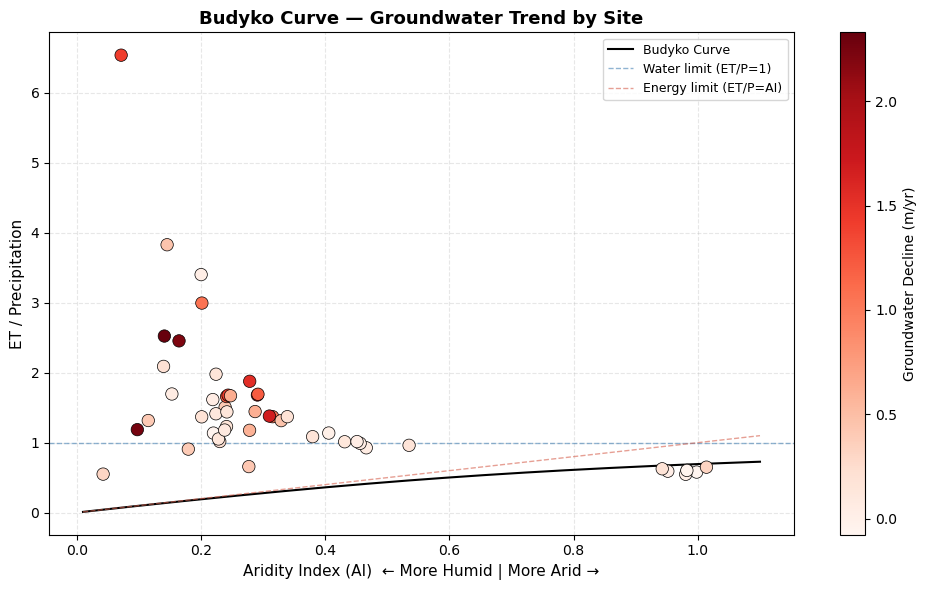

In [5]:

df = pd.read_csv('/capstone/aridgw/outputs/1km/site_summary_1km2.csv')

# --- Budyko theoretical curve ---
# x here is the aridity index (PET/P), y is ET/P
# Budyko: ET/P = [AI * tanh(1/AI) * (1 - exp(-AI))]^0.5
ai_curve = np.linspace(0.01, 1.1, 300)
budyko_y = np.sqrt(ai_curve * np.tanh(1 / ai_curve) * (1 - np.exp(-ai_curve)))

fig, ax = plt.subplots(figsize=(10, 6))

# Budyko curve — plot with inverted x (1/AI becomes AI on flipped axis)
ax.plot(ai_curve, budyko_y, color='black', linewidth=1.5, label='Budyko Curve', zorder=2)

# Water limit (ET/P = 1) and energy limit (ET/P = AI)
ax.axhline(y=1, color='steelblue', linestyle='--', linewidth=1, alpha=0.6, label='Water limit (ET/P=1)')
ax.plot(ai_curve, ai_curve, color='#d6604d', linestyle='--', linewidth=1, alpha=0.6, label='Energy limit (ET/P=AI)')

# Scatter — colored by gw_trend
#cmap = plt.cm.RdBu_r
cmap = plt.cm.Reds


sc = ax.scatter(
    df['AI_1km2'], df['et_precip_ratio'],
    c=df['gw_trend_m_per_yr'], cmap=cmap,
    vmin=df['gw_trend_m_per_yr'].min(), vmax=df['gw_trend_m_per_yr'].max(),
    s=80, edgecolors='black', linewidths=0.5, zorder=4
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Groundwater Decline (m/yr)', fontsize=10)

# Invert x-axis so arid sites are on the right
#ax.invert_xaxis()
#ax.set_xlim(df['AI_1km2'].max() * 1.05, 0)

ax.set_xlabel('Aridity Index (AI)  ← More Humid | More Arid →', fontsize=11)
ax.set_ylabel('ET / Precipitation', fontsize=11)
ax.set_title('Budyko Curve — Groundwater Trend by Site', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('budyko_curve.png', dpi=150)
plt.show()